# Bangalore Mobility Marketplace Performance & Optimization
## Statistical Analysis

**Goal:** Check whether some differences in ride performance are statistically significant.

This analysis focuses on cancellation patterns and uses simple statistical tests that can support business decisions.

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned dataset

file_path = "../data/processed/cleaned_rides.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 34)


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,...,is_weekend,month,month_name,week_of_year,time_period,route,distance_bucket,duration_bucket,fare_bucket,fare_per_km
0,cab economy,2024-07-15,08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,...,False,7,July,29,Morning Peak,balagere harbor → harohalli nagar,Very Long (>15 km),Long (30–60 min),High Fare,29.266446
1,auto,2024-07-05,23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,...,False,7,July,27,Night,basavanagudi 3rd block → bikasipura 1st stage,Very Long (>15 km),Very Long (>60 min),Medium-Low Fare,10.706729
2,auto,2024-07-23,11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,...,False,7,July,30,Daytime,babusapalya cove → kothaguda terrace,Very Long (>15 km),Medium (15–30 min),NaN,NaN
3,cab economy,2024-06-24,08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,...,False,6,June,26,Morning Peak,mahadevapura mews → kanakapura arc,Very Long (>15 km),Very Long (>60 min),Medium-Low Fare,16.059352
4,cab economy,2024-07-15,00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,...,False,7,July,29,Late Night,ganganagar cove → basaveshwaranagar colony,Very Long (>15 km),Very Long (>60 min),Medium-High Fare,24.903712


In [3]:
# Check important columns

print(df[[
    "service_type_clean",
    "is_completed",
    "is_cancelled",
    "is_weekend",
    "time_period",
    "total_fare"
]].head())

print("\nMissing values:")
print(df[[
    "service_type_clean",
    "is_cancelled",
    "is_weekend",
    "total_fare"
]].isnull().sum())

  service_type_clean  is_completed  is_cancelled  is_weekend   time_period  \
0        cab economy             1             0       False  Morning Peak   
1               auto             1             0       False         Night   
2               auto             0             1       False       Daytime   
3        cab economy             1             0       False  Morning Peak   
4        cab economy             1             0       False    Late Night   

   total_fare  
0      796.34  
1      364.35  
2         NaN  
3      500.57  
4      677.63  

Missing values:
service_type_clean       0
is_cancelled             0
is_weekend               0
total_fare            5036
dtype: int64


## 1. Weekday vs Weekend Cancellation

In [4]:
# Compare cancellation rate between weekdays and weekends

weekday_weekend = df.groupby("is_weekend").agg(
    total_rides=("is_cancelled", "count"),
    cancelled_rides=("is_cancelled", "sum")
).reset_index()

weekday_weekend["day_type"] = np.where(
    weekday_weekend["is_weekend"] == True,
    "Weekend",
    "Weekday"
)

weekday_weekend["cancellation_rate"] = (
    weekday_weekend["cancelled_rides"]
    / weekday_weekend["total_rides"]
    * 100
).round(2)

weekday_weekend[[
    "day_type",
    "total_rides",
    "cancelled_rides",
    "cancellation_rate"
]]

,day_type,total_rides,cancelled_rides,cancellation_rate
0,Weekday,36876,3741,10.14
1,Weekend,13124,1295,9.87


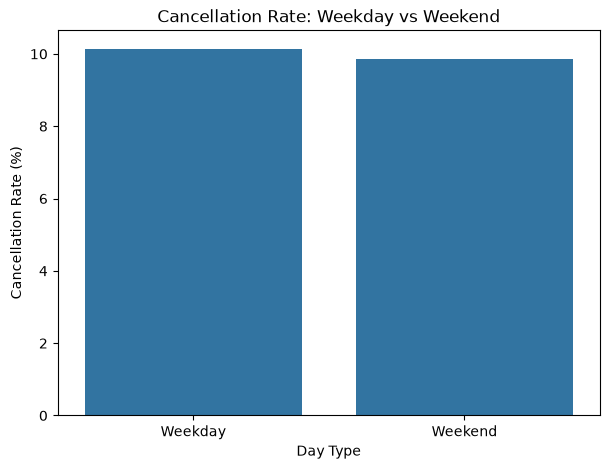

In [5]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=weekday_weekend,
    x="day_type",
    y="cancellation_rate"
)

plt.title("Cancellation Rate: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [6]:
# Create a table of weekend status and cancellation

table = pd.crosstab(
    df["is_weekend"],
    df["is_cancelled"]
)

print(table)

is_cancelled      0     1
is_weekend               
False         33135  3741
True          11829  1295


In [7]:
# Chi-square test

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", round(chi2, 4))
print("p-value:", round(p_value, 4))

Chi-square statistic: 0.7919
p-value: 0.3735


In [8]:
# Interpret the result

if p_value < 0.05:
    print(
        "Result: The relationship between weekend status "
        "and cancellation is statistically significant."
    )
else:
    print(
        "Result: There is not enough evidence to say that "
        "weekend status and cancellation are associated."
    )

Result: There is not enough evidence to say that weekend status and cancellation are associated.


## 2. Cancellation by Service Type

In [9]:
# Cancellation rate by service type

service_cancel = df.groupby("service_type_clean").agg(
    total_rides=("is_cancelled", "count"),
    cancelled_rides=("is_cancelled", "sum")
).reset_index()

service_cancel["cancellation_rate"] = (
    service_cancel["cancelled_rides"]
    / service_cancel["total_rides"]
    * 100
).round(2)

service_cancel.sort_values(
    "cancellation_rate",
    ascending=False
)

,service_type_clean,total_rides,cancelled_rides,cancellation_rate
3,cab economy,10202,1054,10.33
1,bike,15128,1561,10.32
2,bike lite,4884,496,10.16
0,auto,12327,1213,9.84
4,parcel,7459,712,9.55


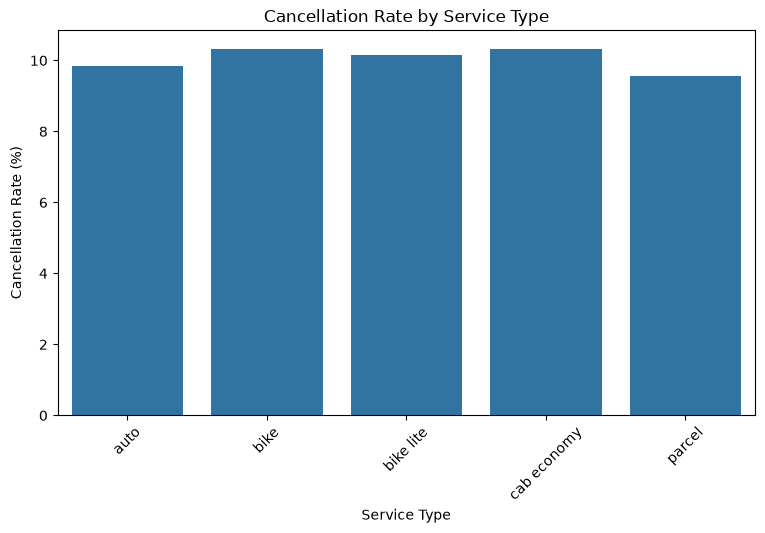

In [10]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=service_cancel,
    x="service_type_clean",
    y="cancellation_rate"
)

plt.title("Cancellation Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Check whether service type and cancellation are associated

service_table = pd.crosstab(
    df["service_type_clean"],
    df["is_cancelled"]
)

print(service_table)

is_cancelled            0     1
service_type_clean             
auto                11114  1213
bike                13567  1561
bike lite            4388   496
cab economy          9148  1054
parcel               6747   712


In [12]:
# Chi-square test for service type and cancellation

chi2_service, p_service, dof_service, expected_service = (
    chi2_contingency(service_table)
)

print("Chi-square statistic:", round(chi2_service, 4))
print("p-value:", round(p_service, 4))

Chi-square statistic: 4.8249
p-value: 0.3057


In [13]:
if p_service < 0.05:
    print(
        "Result: Service type and cancellation are "
        "statistically associated."
    )
else:
    print(
        "Result: There is not enough evidence to say that "
        "service type and cancellation are associated."
    )

Result: There is not enough evidence to say that service type and cancellation are associated.


## 3. Fare Analysis

Cancelled rides in this dataset have missing fare values. Therefore, I do not compare cancelled and completed ride fares directly. Instead, fare analysis is performed only where fare data is available.

In [14]:
# Fare analysis for completed rides

completed_fares = df[
    (df["is_completed"] == 1) &
    (df["total_fare"].notna())
]["total_fare"]

print("Completed rides with fare:", len(completed_fares))
print("Average fare:", round(completed_fares.mean(), 2))
print("Median fare:", round(completed_fares.median(), 2))

Completed rides with fare: 44964
Average fare: 547.39
Median fare: 544.92


In [15]:
# Average fare by service type

fare_service = df[
    df["total_fare"].notna()
].groupby("service_type_clean").agg(
    rides_with_fare=("total_fare", "count"),
    average_fare=("total_fare", "mean"),
    median_fare=("total_fare", "median")
).reset_index()

fare_service["average_fare"] = fare_service["average_fare"].round(2)
fare_service["median_fare"] = fare_service["median_fare"].round(2)

fare_service.sort_values(
    "average_fare",
    ascending=False
)

,service_type_clean,rides_with_fare,average_fare,median_fare
0,auto,11114,548.83,549.96
1,bike,13567,547.86,542.43
3,cab economy,9148,547.25,545.34
4,parcel,6747,546.39,543.79
2,bike lite,4388,544.15,540.36


## 4. Business Summary

In [16]:
print("Statistical Analysis Summary")
print("-" * 40)

print(
    f"Overall cancellation rate: "
    f"{df['is_cancelled'].mean() * 100:.2f}%"
)

print(
    f"Chi-square p-value (weekend vs cancellation): "
    f"{p_value:.4f}"
)

print(
    f"Chi-square p-value (service type vs cancellation): "
    f"{p_service:.4f}"
)

print(
    "\nThese tests help identify whether observed differences "
    "in cancellation patterns are likely to represent meaningful "
    "relationships rather than random variation."
)

Statistical Analysis Summary
----------------------------------------
Overall cancellation rate: 10.07%
Chi-square p-value (weekend vs cancellation): 0.3735
Chi-square p-value (service type vs cancellation): 0.3057

These tests help identify whether observed differences in cancellation patterns are likely to represent meaningful relationships rather than random variation.
